In [1]:
!pip install chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 62.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=d48f091ac2e7a594a26061acc0211586edfbbc54d40d76bdd5e32b77f9471fc1
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


In [2]:
import pandas as pd
import kagglehub
import os
import chess
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, mixed_precision
mixed_precision.set_global_policy("mixed_float16")


In [3]:
path = kagglehub.dataset_download("ronakbadhe/chess-evaluations")

100%|██████████| 200M/200M [00:06<00:00, 32.8MB/s]

Extracting files...


In [4]:
data = pd.read_csv(os.path.join(path, "chessData.csv"))

In [5]:
data.head()

,FEN,Evaluation
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,+56
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,+52
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26


In [6]:
len(data)

12958035

In [7]:
data = pd.concat([data, pd.read_csv(os.path.join(path, "random_evals.csv"))])

In [8]:
data = data[~data['Evaluation'].str.contains("#")]

In [9]:
data['Evaluation'] = data['Evaluation'].astype(np.float32)

In [10]:
len(data)

13711890

In [11]:
data.head()

,FEN,Evaluation
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10.0
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,56.0
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9.0
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,52.0
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26.0


In [12]:
data.max()

,0
FEN,rrqnn1k1/p2b1pbp/Q2p2p1/B1pPp3/2P5/1R3NP1/P2NP...
Evaluation,15319.0


In [13]:
data.min()

,0
FEN,1B1K2k1/1R4p1/5p2/8/r7/6P1/8/8 w - - 87 100
Evaluation,-15312.0


In [14]:
data

,FEN,Evaluation
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10.0
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,56.0
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9.0
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,52.0
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26.0
...,...,...
1000268,r1b1k2r/p2p1pp1/4pb1p/qp6/NnP5/P7/4PPPP/1R1QKB...,-386.0
1000269,r1b1k2r/p2p1pp1/1p2pb1p/q7/NnP5/P7/4PPPP/1R1QK...,255.0
1000270,r1b1k2r/pp1p1pp1/q3pb1p/8/NnP5/P7/4PPPP/1R1QKB...,89.0
1000271,r1b1k2r/pp1p1p2/4pbpp/q7/NnP5/P7/4PPPP/1R1QKBN...,333.0


In [15]:
len(data)

13711890

In [16]:
def getturn(fen):
  return 1 if fen.split(" ")[1] == 'w' else 0

In [17]:
data['turn'] = data['FEN'].apply(getturn)

In [18]:
data[data['turn'] == 1]

,FEN,Evaluation,turn
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,56.0,1
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,52.0,1
5,rnbqkb1r/ppp2ppp/4pn2/3p4/3PP3/8/PPPN1PPP/R1BQ...,50.0,1
7,rnbqkb1r/pppn1ppp/4p3/3pP3/3P4/8/PPPN1PPP/R1BQ...,75.0,1
9,rnbqkb1r/pp1n1ppp/4p3/2ppP3/3P1P2/8/PPPN2PP/R1...,52.0,1
...,...,...,...
1000268,r1b1k2r/p2p1pp1/4pb1p/qp6/NnP5/P7/4PPPP/1R1QKB...,-386.0,1
1000269,r1b1k2r/p2p1pp1/1p2pb1p/q7/NnP5/P7/4PPPP/1R1QK...,255.0,1
1000270,r1b1k2r/pp1p1pp1/q3pb1p/8/NnP5/P7/4PPPP/1R1QKB...,89.0,1
1000271,r1b1k2r/pp1p1p2/4pbpp/q7/NnP5/P7/4PPPP/1R1QKBN...,333.0,1


In [19]:
data[(data['turn'] == 0)&(data['Evaluation'] > 0)]

,FEN,Evaluation,turn
6,rnbqkb1r/ppp2ppp/4pn2/3pP3/3P4/8/PPPN1PPP/R1BQ...,10.0,0
8,rnbqkb1r/pppn1ppp/4p3/3pP3/3P1P2/8/PPPN2PP/R1B...,52.0,0
10,rnbqkb1r/pp1n1ppp/4p3/2ppP3/3P1P2/2P5/PP1N2PP/...,32.0,0
12,r1bqkb1r/pp1n1ppp/2n1p3/2ppP3/3P1P2/2P2N2/PP4P...,25.0,0
14,r1bqkb1r/pp1n1ppp/2n1p3/3pP3/3P1P2/5N2/PP4PP/R...,7.0,0
...,...,...,...
999627,4r3/1p2r2p/p4kp1/8/4pP2/PP2R3/2P1R1PP/6K1 b - ...,78.0,0
999628,4r3/1p2r2p/p4kp1/8/4pPP1/1P2R3/P1P1R2P/6K1 b -...,90.0,0
999629,4r3/1p2r2p/p4kp1/8/P3pP2/1P2R3/2P1R1PP/6K1 b -...,119.0,0
999635,4r3/1p2r2p/p4kp1/8/4pP2/1P2R1P1/P1P1R2P/6K1 b ...,128.0,0


In [20]:
data.loc[data['turn'] == 0, 'Evaluation'] = -data.loc[data['turn'] == 0, 'Evaluation']

<Axes: ylabel='Frequency'>

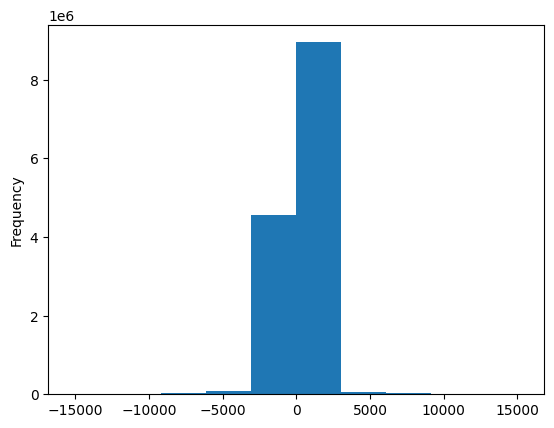

In [22]:
data['Evaluation'].plot.hist()

In [23]:
data = data[(data['Evaluation'] > -2500) & (data['Evaluation'] < 2500)]

In [24]:
data['Evaluation'] = data['Evaluation'].apply(lambda x: np.tanh(x/400))

/tmp/ipykernel_585/3201608329.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Evaluation'] = data['Evaluation'].apply(lambda x: np.tanh(x/400))


In [25]:
len(data)

13483866

In [26]:
def tf_board_to_vector(fen, score):
    x ,y= tf.numpy_function(
        board_to_vector,
        [fen, score],
        [tf.int8, tf.float32]
    )

    x.set_shape((768,))
    y.set_shape(())

    return x, y

In [27]:
PIECE_CHAR_TO_TYPE = {'p': 0, 'n': 1, 'b': 2, 'r': 3, 'q': 4}

def parse_fen(fen):
    placement, turn = fen.split(' ', 2)[:2]
    pieces = []
    king_sq = [None, None]

    rank, file = 7, 0
    for ch in placement:
        if ch == '/':
            rank -= 1
            file = 0
        elif ch.isdigit():
            file += int(ch)
        else:
            is_white = ch.isupper()
            square = rank * 8 + file
            if ch.lower() == 'k':
                king_sq[is_white] = square
            else:
                pieces.append((square, PIECE_CHAR_TO_TYPE[ch.lower()], is_white))
            file += 1

    us_is_white = (turn == 'w')
    return pieces, king_sq, us_is_white

In [28]:
def mirror_sq(square):
    return square ^ 56

def orient(square, perspective_is_white):
    return square if perspective_is_white else mirror_sq(square)

def halfkp_from_parsed(pieces, king_sq, perspective_is_white):
    k = orient(king_sq[perspective_is_white], perspective_is_white)
    indices = []
    for square, ptype, is_white in pieces:
        relative = 0 if is_white == perspective_is_white else 1
        p_idx = relative * 5 + ptype
        sq = orient(square, perspective_is_white)
        indices.append(k * 640 + p_idx * 64 + sq)
    return indices

def board_to_halfkp(fen):
    pieces, king_sq, us_is_white = parse_fen(fen)
    us_idx = halfkp_from_parsed(pieces, king_sq, us_is_white)
    them_idx = halfkp_from_parsed(pieces, king_sq, not us_is_white)
    return np.array(us_idx, dtype=np.int32), np.array(them_idx, dtype=np.int32)

In [29]:
train_fen, test_fen, y_train, y_test = train_test_split(data['FEN'], data['Evaluation'], test_size=.2, random_state=42)
train_fen, val_fen, y_train, y_val = train_test_split(train_fen, y_train, test_size=.2, random_state= 42)

In [30]:
MAX_PIECES = 32

def pad_indices(idx):
    padded = np.full(MAX_PIECES, -1, dtype=np.int32)
    padded[:len(idx)] = idx
    return padded

In [31]:
def create_example(fen, score):
    us_idx, them_idx = board_to_halfkp(fen)
    us_idx, them_idx = pad_indices(us_idx), pad_indices(them_idx)
    feature = {
        "us_idx": tf.train.Feature(int64_list=tf.train.Int64List(value=us_idx.tolist())),
        "them_idx": tf.train.Feature(int64_list=tf.train.Int64List(value=them_idx.tolist())),
        "score": tf.train.Feature(float_list=tf.train.FloatList(value=[score])),
    }
    return tf.train.Example(features=tf.train.Features(feature=feature)).SerializeToString()

In [32]:
steps = len(train_fen)//512

In [33]:
with tf.io.TFRecordWriter("train.tfrecord") as writer:
    for board, score in zip(train_fen, y_train):
        writer.write(create_example(board, score))

In [34]:
with tf.io.TFRecordWriter("val.tfrecord") as writer:
    for board, score in zip(val_fen, y_val):
        writer.write(create_example(board, score))

In [35]:
with tf.io.TFRecordWriter("test.tfrecord") as writer:
    for board, score in zip(test_fen, y_test):
        writer.write(create_example(board, score))

In [37]:
feature_description = {
    "us_idx": tf.io.FixedLenFeature([MAX_PIECES], tf.int64),
    "them_idx": tf.io.FixedLenFeature([MAX_PIECES], tf.int64),
    "score": tf.io.FixedLenFeature([], tf.float32),
}

def parse(serialized_example):
    parsed = tf.io.parse_single_example(serialized_example, feature_description)
    us_idx = tf.cast(parsed["us_idx"], tf.int32)
    them_idx = tf.cast(parsed["them_idx"], tf.int32)
    score = tf.cast(parsed["score"], tf.float32)
    return {"us_idx": us_idx, "them_idx": them_idx}, score

In [38]:
train_dataset = (
    tf.data.TFRecordDataset("train.tfrecord")
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(100000)
    .repeat()
    .batch(512)
    .prefetch(tf.data.AUTOTUNE)
)

In [39]:
val_dataset = (
    tf.data.TFRecordDataset("val.tfrecord")
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(512)
    .prefetch(tf.data.AUTOTUNE)
)

In [45]:
EMBED_DIM = 256

def build_model():
    us_input = layers.Input(shape=(MAX_PIECES,), dtype=tf.int32, name="us_idx")
    them_input = layers.Input(shape=(MAX_PIECES,), dtype=tf.int32, name="them_idx")

    embed = layers.Embedding(input_dim=40961, output_dim=EMBED_DIM)

    us_shifted = us_input + 1
    them_shifted = them_input + 1
    mask_us = tf.keras.ops.cast(tf.keras.ops.not_equal(us_input, -1), "float32")[..., None]
    mask_them = tf.keras.ops.cast(tf.keras.ops.not_equal(them_input, -1), "float32")[..., None]

    us_vec = tf.keras.ops.sum(embed(us_shifted) * mask_us, axis=1)
    them_vec = tf.keras.ops.sum(embed(them_shifted) * mask_them, axis=1)

    x = layers.Concatenate()([us_vec, them_vec])

    x = layers.Dense(256)(x); x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Dense(256)(x); x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Dense(128)(x); x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Dense(64)(x);  x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    out = layers.Dense(1)(x)

    return tf.keras.Model(inputs={"us_idx": us_input, "them_idx": them_input}, outputs=out)

model = build_model()

In [46]:
model.compile(
    optimizer='adam',
    loss="mean_absolute_error",
    metrics=['mse']
)

In [47]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
model.fit(train_dataset, epochs=40, validation_data=val_dataset, callbacks=[early_stopping], steps_per_epoch=steps)

Epoch 1/40
16854/16854 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3022 - mse: 0.1810

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16854/16854 ━━━━━━━━━━━━━━━━━━━━ 610s 36ms/step - loss: 0.2719 - mse: 0.1506 - val_loss: 0.2359 - val_mse: 0.1205
Epoch 2/40
16854/16854 ━━━━━━━━━━━━━━━━━━━━ 578s 34ms/step - loss: 0.2202 - mse: 0.1081 - val_loss: 0.2125 - val_mse: 0.1026
Epoch 3/40
16854/16854 ━━━━━━━━━━━━━━━━━━━━ 609s 36ms/step - loss: 0.1998 - mse: 0.0921 - val_loss: 0.2031 - val_mse: 0.0960
Epoch 4/40
16854/16854 ━━━━━━━━━━━━━━━━━━━━ 594s 35ms/step - loss: 0.1877 - mse: 0.0829 - val_loss: 0.1973 - val_mse: 0.0918
Epoch 5/40
16854/16854 ━━━━━━━━━━━━━━━━━━━━ 594s 35ms/step - loss: 0.1790 - mse: 0.0764 - val_loss: 0.1931 - val_mse: 0.0886
Epoch 6/40
16854/16854 ━━━━━━━━━━━━━━━━━━━━ 620s 37ms/step - loss: 0.1724 - mse: 0.0716 - val_loss: 0.1901 - val_mse: 0.0874
Epoch 7/40
16854/16854 ━━━━━━━━━━━━━━━━━━━━ 582s 35ms/step - loss: 0.1670 - mse: 0.0677 - val_loss: 0.1891 - val_mse: 0.0866
Epoch 8/40
12837/16854 ━━━━━━━━━━━━━━━━━━━━ 2:03 31ms/step - loss: 0.1638 - mse: 0.0655

In [ ]:
model.save("chess.keras")

In [ ]:
us_idx, them_idx = board_to_halfkp("4k3/8/8/8/2q5/8/8/4K3 b - - 0 1")
us_idx = pad_indices(us_idx)[None, :]
them_idx = pad_indices(them_idx)[None, :]

prediction = model.predict({"us_idx": us_idx, "them_idx": them_idx})
print(prediction)

In [ ]:
test_dataset = (
    tf.data.TFRecordDataset("test.tfrecord")
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(512)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
model.evaluate(test_dataset)

In [ ]:
us_idx, them_idx = board_to_halfkp("rnbqkbnr/pppppppp/8/7Q/2B5/8/PPPPPPPP/RNB1K1NR b KQkq - 0 1")
us_idx = pad_indices(us_idx)[None, :]
them_idx = pad_indices(them_idx)[None, :]

prediction = model.predict({"us_idx": us_idx, "them_idx": them_idx})
print(prediction)